## Topic

Reproducibility; Model Versioning; Serving; Rollback

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/reproducibility-model-versioning-serving-rollback.html)。

## Question

What is Reproducibility; Model Versioning; Serving; Rollback, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Reproducibility; Model Versioning; Serving; Rollback

## Learning Goal

A deployed model needs a versioned preprocessing contract, model artifact, data reference and code reference. Loading a trusted artifact should reproduce predictions; untrusted pickle files can execute code.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Round-trip a tiny model in a temporary directory and verify prediction equality. Change feature ordering deliberately and explain why a schema check is necessary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


{
  "features": [
    "past20",
    "abs_lag0"
  ],
  "data_sha256": "4e04ec366d019e71df353243acf363623a788a31ed4c3d052d5528f0016cce5a",
  "artifact_sha256": "a294081715d28eaceadeacd2934147abe9f20db5d18354576f4054ea41486a47",
  "code_version": "learning-fixture-v1"
}


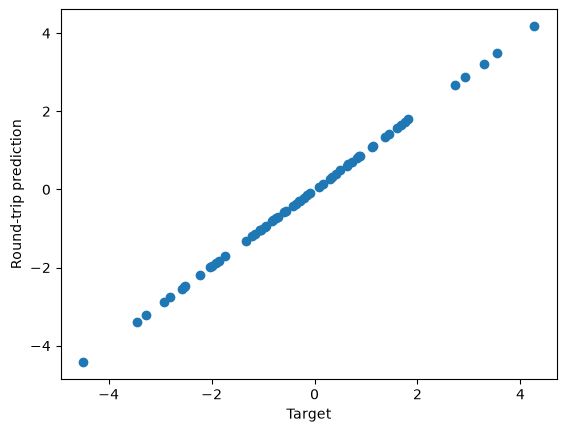

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import tempfile,pickle,hashlib,json
from pathlib import Path
rng=np.random.default_rng(7);X=rng.normal(size=(60,2));y=X[:,0]*2-X[:,1]
model=make_pipeline(StandardScaler(),Ridge()).fit(X,y)
with tempfile.TemporaryDirectory() as directory:
    path=Path(directory)/"trusted_local_model.pkl";path.write_bytes(pickle.dumps(model))
    manifest={"features":["past20","abs_lag0"],"data_sha256":hashlib.sha256(X.tobytes()).hexdigest(),"artifact_sha256":hashlib.sha256(path.read_bytes()).hexdigest(),"code_version":"learning-fixture-v1"}
    loaded=pickle.loads(path.read_bytes());assert np.allclose(model.predict(X),loaded.predict(X));print(json.dumps(manifest,indent=2))
plt.scatter(y,loaded.predict(X));plt.xlabel("Target");plt.ylabel("Round-trip prediction");plt.show()

## Expected Observations

Artifact equality does not guarantee production correctness; also validate feature names, units, timing and environment versions. Roll back model and preprocessing together.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. A deployed model needs a versioned preprocessing contract, model artifact, data reference and code reference. Loading a trusted artifact should reproduce predictions; untrusted pickle files can execute code.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Artifact equality does not guarantee production correctness; also validate feature names, units, timing and environment versions. Roll back model and preprocessing together.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/reproducibility-model-versioning-serving-rollback.html)
